In [13]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

WCSS values: [60000.00000000007, 52476.0179536479, 47831.19417317977, 44098.4719511719, 41343.53619291589, 38845.242662565084, 36822.85543268553, 35163.08744013599, 33652.345265302385]


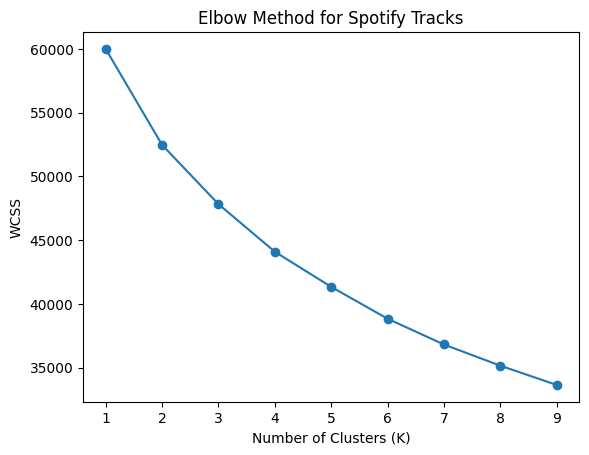

In [19]:
df=pd.read_csv("spotify_tracks_with_metadata_10000.csv")

features=["danceability","energy","valence","tempo","duration_ms","popularity"]
X=df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values:", wcss)

plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Spotify Tracks")
plt.show()


In [15]:

best_k = 4    # <-- CHANGE THIS BASED ON YOUR ELBOW GRAPH

kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df['cluster'] = kmeans_final.fit_predict(X_scaled)


In [17]:
print(df[["track_name", "cluster"]])
 
import joblib
 
joblib.dump(kmeans, "spotify_predictor.pkl")

            track_name  cluster
0             Love Sky        3
1           Fire Dream        0
2          Light Night        2
3      Love Wave Night        1
4           Fire Light        0
...                ...      ...
9995    Beat Sky Night        3
9996    Sky Night Fire        2
9997         Fire Beat        0
9998  Heart Love Dream        0
9999  Wave Night Heart        0

[10000 rows x 2 columns]


['spotify_predictor.pkl']